In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

virids_color = cm.viridis(np.linspace(0,1,5))
primary_color = virids_color[0]
secondary_color = virids_color[1]
accent_color = virids_color[2]
danger_color = '#800000'
neutral_color = virids_color[4]
custome_palate = virids_color

In [3]:
df = pd.read_csv('clean_data.csv')
display(df.head(5))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,...,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order_process_time,delay,is_delay,order_month,order_day,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11


0          91.250000
3          22.860001
4         134.210007
5          95.180000
6          68.430000
             ...    
172759    119.989998
172760     40.000000
172762    141.110001
172763    186.229996
172764    168.949997
Name: Order Profit Per Order, Length: 139354, dtype: float64

profitability_flag
profit        139354
loss           32295
break down      1116
Name: count, dtype: int64

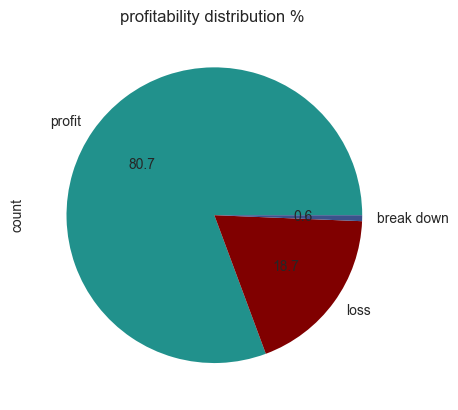

In [19]:
# find out company's profit or loss summury
profits_positive = df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order']
display(profits_positive)

# profitability flag base on order profit per order
df['profitability_flag'] = np.where(df['Order Profit Per Order']> 0 , 'profit', np.where(df['Order Profit Per Order'] < 0 ,'loss' , 'break down'))
profit_count = df['profitability_flag'].value_counts()
display(profit_count)
profit_count.plot(kind='pie' , autopct = '%1.1f' , colors = [accent_color , danger_color , secondary_color])
plt.title('profitability distribution % ')
plt.show()

In [ ]:
metrics = {}
delivery_late = df[df['delay'] > 0]
metrics['total_order'] = len(df)
metrics['late_delivery'] = len(delivery_late)
metrics['on_time_delivery'] = len(df[df['delay'] == 0])
metrics['total_profit'] = df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
metrics['total_loss_due_to_delay'] = df.loc[df['delay'] > 0, 'Order Profit Per Order'].sum()

print("----business KPI------")
for k , v in metrics.items():
    if isinstance(v , float):
        print(f'{k} : {v:.2f}')
    else:
        print(f'{k} : {v:.2f}')



----business KPI------
total_order : 172765.00
late_delivery : 94523.00
on_time_delivery : 36650.00
total_profit : 7514813.81
total_loss_due_to_delay : 2055765.16


# profitability vs delivery time analysis

In [35]:
profit_metrix = df.groupby('delay')['Order Profit Per Order'].agg(
    avg_profit = 'mean',
    total_profit = 'sum',
    order_count = 'count'
)
display(profit_metrix)

,avg_profit,total_profit,order_count
delay,,,
-2,23.360134,4.875961e+05,20873
-1,21.604769,4.476292e+05,20719
0,22.249118,8.154302e+05,36650
1,22.333227,1.194895e+06,53503
2,21.128491,5.821110e+05,27551
3,20.031412,1.356527e+05,6772
4,21.368783,1.431067e+05,6697


In [40]:
delay_distribution = (df['delay'].value_counts(normalize=True) * 100).reset_index()
display(delay_distribution)

,delay,proportion
0,1,30.968657
1,0,21.213788
2,2,15.947096
3,-2,12.081730
4,-1,11.992591
5,3,3.919775
6,4,3.876364


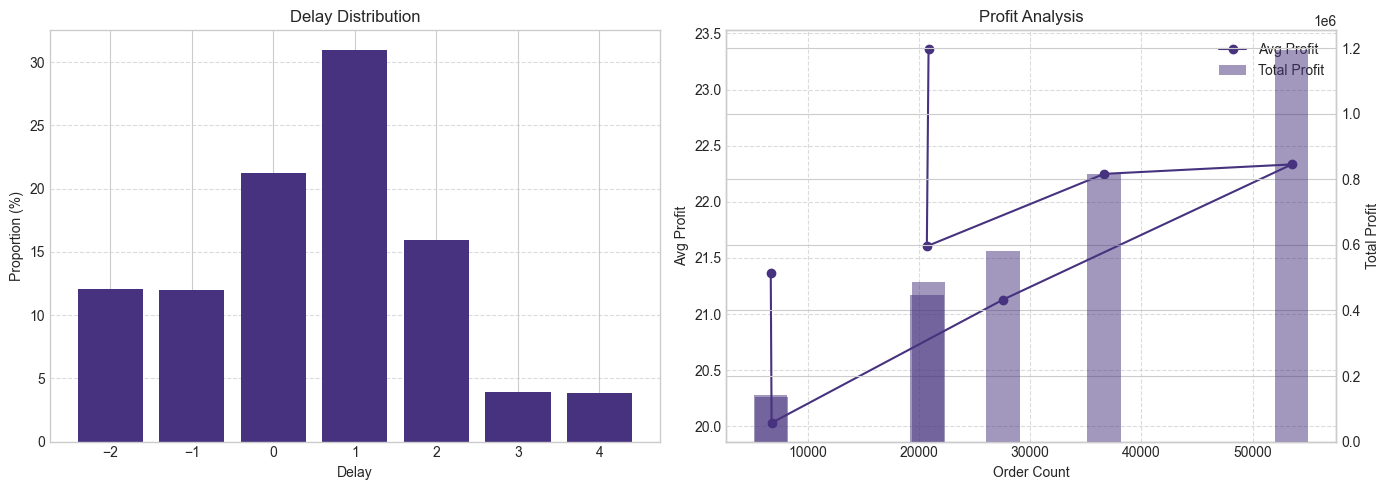

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------
# Chart 1: Delay Distribution
# -------------------------------
axes[0].bar(delay_distribution["delay"], delay_distribution["proportion"])
axes[0].set_title("Delay Distribution")
axes[0].set_xlabel("Delay")
axes[0].set_ylabel("Proportion (%)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# -------------------------------
# Chart 2: Profit Matrix
# -------------------------------
ax1 = axes[1]

# Avg Profit (LINE)
ax1.plot(
    profit_metrix["order_count"],
    profit_metrix["avg_profit"],
    marker='o',
    label="Avg Profit",
    zorder=3  # keep line above grid
)
ax1.set_xlabel("Order Count")
ax1.set_ylabel("Avg Profit")

# Total Profit (BAR)
ax2 = ax1.twinx()
ax2.bar(
    profit_metrix["order_count"],
    profit_metrix["total_profit"],
    width=3000,     
    alpha=0.5,
    label="Total Profit",
    zorder=2
)
ax2.set_ylabel("Total Profit")

# Title
ax1.set_title("Profit Analysis")

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

ax1.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()